# Data & Packages

In [1]:
# Main packages
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Time constants
MINUTES_PER_WEEK = 7 * 24 * 60
N_WEEKS = 8
EIGHT_WEEKS_SECONDS = N_WEEKS * MINUTES_PER_WEEK * 60


In [3]:
# Load data
df = pl.scan_csv("/home/lanl/data/cyber1/auth.txt.gz", has_header=False, separator=",",
                 new_columns=['time','src_user','dest_user','src_comp','dest_comp',
                              'auth_type','logon_type','auth_orientation','outcome'])

In [4]:
# Keep only human users
df = df.filter(pl.col('src_user').str.starts_with('U'))

In [5]:
# Keep the first 8 weeks of data
df = df.filter(pl.col('time') < EIGHT_WEEKS_SECONDS)

In [6]:
# Distinct (user, minute) points 
user_minutes = (
    df.select(
        'src_user',
        minute = pl.col('time') // 60,
    )
    .unique()
    .collect(engine='streaming')
)

# Functions

In [7]:
# Jaccard index for consecutive weeks
def jaccard_by_week(AGG_HOURS):

    AGG_MINUTES = round(AGG_HOURS * 60)  
   
    points = (
        user_minutes.select(
            'src_user',
            week = pl.col('minute') // MINUTES_PER_WEEK,
            relative_bucket = (pl.col('minute') % MINUTES_PER_WEEK) // AGG_MINUTES,
        )
        .unique()
    )

    jaccards = []

    for week in range(N_WEEKS - 1):

        w_curr = points.filter(pl.col('week') == week)
        w_next = points.filter(pl.col('week') == week + 1)

        overlap = w_curr.join(w_next, on=['src_user', 'relative_bucket'], how='inner')

        union = len(w_curr) + len(w_next) - len(overlap)

        jaccards.append(len(overlap) / union)

    return np.array(jaccards)

# JACCARD

In [8]:
# Aggregation levels in hours (1 week is the user-persistence limit)
levels = {'1 min': 1/60, '10 min': 1/6, '30 min': 0.5, '1 h': 1, '2 h': 2,
          '3 h': 3, '4 h': 4, '6 h': 6, '8 h': 8, '12 h': 12,
          '24 h': 24, '1 week': 168}

In [9]:
# Jaccard values for each aggregation level
results = {name: jaccard_by_week(h) for name, h in levels.items()}

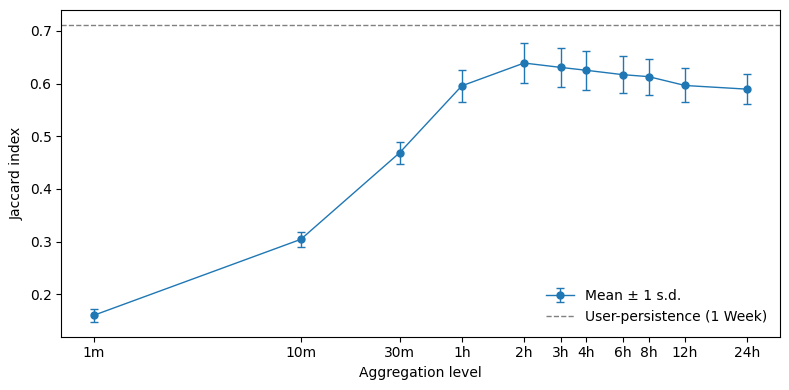

In [10]:
# Plot of jaccard mean ± 1 s.d for each aggregtion level
fig, ax = plt.subplots(figsize=(8, 4))

agg_levels = np.array([h for name, h in levels.items() if name != '1 week'])
jaccards = [results[name] for name in levels if name != '1 week']

means = np.array([js.mean() for js in jaccards])
sds = np.array([js.std(ddof=1) for js in jaccards])

ax.errorbar(agg_levels, means, yerr=sds, marker='o', ms=5, lw=1,
            color='tab:blue', capsize=3, elinewidth=1,
            label='Mean ± 1 s.d.')

persistence = results['1 week'].mean()
ax.axhline(persistence, ls='--', lw=1, color='grey',
           label='User-persistence (1 Week)')

ax.set_xscale('log')
ax.set_xticks(agg_levels)
ax.set_xticklabels(['1m','10m','30m','1h','2h','3h','4h','6h','8h','12h','24h'])
ax.minorticks_off()
ax.set_xlabel('Aggregation level')
ax.set_ylabel('Jaccard index')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], frameon=False, loc='lower right')
plt.tight_layout()

plt.savefig('jaccard_plot.pdf', format='pdf')

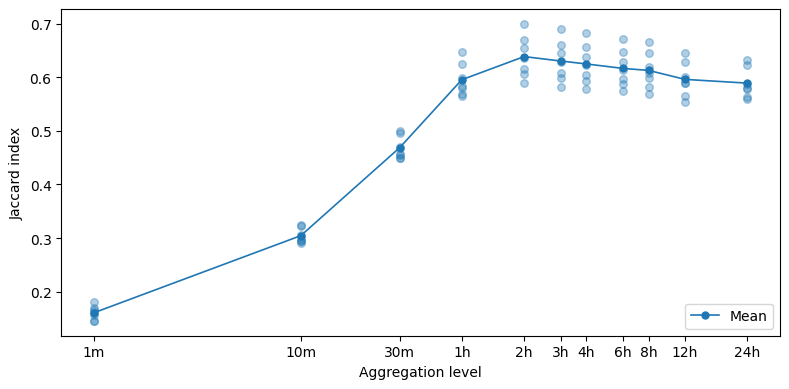

In [11]:
# Plot of jaccards & mean for each aggregtion level
fig, ax = plt.subplots(figsize=(8, 4))

agg_levels = np.array([h for name, h in levels.items() if name != '1 week'])
jaccards = [results[name] for name in levels if name != '1 week']

means = np.array([js.mean() for js in jaccards])

for x, js in zip(agg_levels, jaccards):
    ax.scatter(x * np.ones(len(js)), js, color='tab:blue', alpha=0.35, s=30, zorder=2)

ax.plot(agg_levels, means , marker='o', ms=5, lw=1.2, zorder=3, label='Mean')

ax.set_xscale('log')
ax.set_xticks(agg_levels)
ax.set_xticklabels(['1m','10m','30m','1h','2h','3h','4h','6h','8h','12h','24h'])
ax.minorticks_off()
ax.set_xlabel('Aggregation level')
ax.set_ylabel('Jaccard index')
ax.legend(loc='lower right')
plt.tight_layout()

In [14]:
import pandas as pd

df = pd.DataFrame(results)                     # columns = aggregation levels (incl. '1 week')
df.index = [f"{w+1}-{w+2}" for w in range(N_WEEKS - 1)]   # row i -> "week (i+1)-(i+2)"
df.index.name = "Week pair"

# optional: enforce column order, drop '1 week' if you only want the aggregation-level columns
col_order = ['1 min','10 min','30 min','1 h','2 h','3 h','4 h','6 h','8 h','12 h','24 h']
df = df[col_order]

df.to_csv("jaccard_by_aggregation.csv")